In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

[27.72569315]
-1.3831039511412029


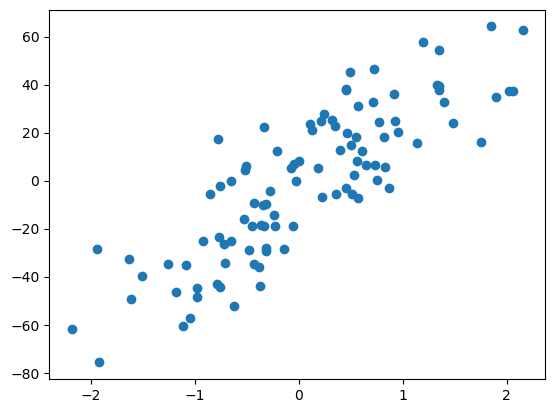

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

In [7]:
y_pred = reg.predict(X_test)

In [9]:
print("Accuracy score before Lasso Regression:",r2_score(y_test,y_pred)*100)

Accuracy score before Lasso Regression: 54.907713522700895


In [24]:
L = Lasso(alpha=2)
L.fit(X_train,y_train)
print(L.coef_)
print(L.intercept_)

[25.49292202]
-1.0781108434379303


In [25]:
y_pred1 = L.predict(X_test)

In [26]:
print("Accuracy score on alpha=5:",r2_score(y_test,y_pred1)*100)

Accuracy score on alpha=5: 53.915507865176494


r2_Score After alpha=0 54.90771352270091
r2_Score After alpha=1 54.54176562640705
r2_Score After alpha=5 50.47487539186466
r2_Score After alpha=10 39.53429063761107
r2_Score After alpha=30 -31.226349594169434


C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\base.py:1474: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.080e+04, tolerance: 7.669e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

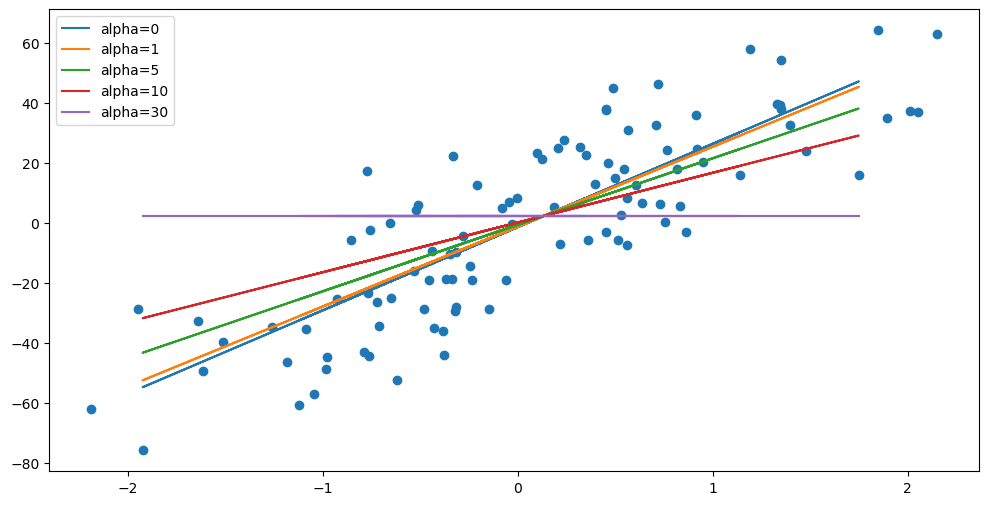

In [34]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    y_pred = L.predict(X_test)
    print("r2_Score After alpha={}".format(i),r2_score(y_test,y_pred)*100)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()
    